<a href="https://colab.research.google.com/github/Carlos-PC05/FinalProjectCS-362/blob/17apr/FinalReport_SP26_RV_PC_MASTERFILE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

----

## Reminders before submitting any phase

### Please delete this section/these reminders BEFORE your final final submission at the end of the semester

* **TECHNIQUES FROM CLASS**:  Be sure to rely on your techniques from class when working on your project.  Points wil  be deducted if you skip over relevant technqiques that should  be considered.  Examples:
    * Correlation coefficents should be given for scatterplots;
    * If you give a p-value (which you should at some point), you should interpret it and also be sure to include the null and alternative hypotheses.
    * If you're doing a regression, be sure to desicuss the properties of the residual plot.
    * GridSearchCV should be used to help hypertune your parameters.
    * etc.
* **FLOW**: Eventually, you need to have FLOW in your project, where one section flows into the next.
    * So each section should have an opening sentence for readibility introducing the point of the section.
    * Also, at the end of the section, you must include a discussion of what question you plan to ask next or where your analysis is heading.
    * Your goal is to create a *READABLE*, professional writeup.
* **AUDIENCE**:   Your audience is a company, not an educator.  So pretend you are a consultant for a company and presenting results to them.  Be professional.  Include any background that the reader might need to know to understand the question.
* **GRAPHS**:  We love them.  Be sure to xplain what you learn from the graph AFTER the graph picture.
    * Each graph needs a title, y axis labels, and x axis labels, and legends if necessary.   
* **TABLE OF CONTENTS:**  You need an organized table of contents showing all your subsections and helping the reader read through your document.
* There should be **no crappy "text"** printed before each picture.
    * Add a semicolon to the last line int he code cell to prevent this.
* In each code cell, **there must be a code comment** explaining what is going on in the code cell.
    * NOOOOOOO results should be discussed in the hashtag areas
    * Example of a good code comment:  #In this code cell, we build a line graph of the number of reservations across time.
* If there is **anything special going on in your code cell, that should be documented and explained with code comments**  and possibly in the discussion before the code cell, if appropriate.
    * For example, if you are filtering on a special condition (like where tuition > 0 for some reason) then explain why.
* **Long Code:**  Coders don't like to scroll right!
    * If you have long code that extends to the right so that I'd have to scroll to see it, then just hit enter after a comma and the code will be placed indented on the next line for you.   
* **"Significant"** ->  Only use this word if you have done a hypothesis test... "There is a **significant** difference between the average launch angle in 2022 and in 2015."
    * If not using a hypothesis test/p-value, then use a synonym like  **striking**.
    * So know that the word "significant"  requires statistical evidence.  
* **Correlation does NOT imply causation** so don't accidentally use lingo that suggests that "variable X" is CAUSING some change in varaiable Y:
    * SHOULD NOT SAY:  
        * X is impacting Y
        * X causes Y
        * X contributes to Y
        * X influences to Y
        * X leads to Y
        * X increases Y
        * etc
    * Instead, just keep your lingo speculative and then you can make guesses:
      * It is possible that we see this effect because of XXX.
      * Perhaps this makes sense because XXX.

---

In [173]:
pip install kagglehub

In [174]:
# imports go here
import os

#For reading the dataset
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr  #to calculate the correlation coefficient r

#For the regression model
from sklearn.linear_model import LinearRegression
#for splitting
from sklearn.model_selection import train_test_split
#for calculating MAE, MSE
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


---
#### CS 362 - Machine Learning - Final Project - SP26

---
# Predicting Cognitive Decline

### By: Carlos Parra Camacho and Raymond Vargas Pérez


---

## 1. Introduction

For this project, our group explored... (This section will be finished at a later date and can be skipped at this time.)

When you do write it: I expect 2-3 paragraphs, more if needed.

---

## 2. Data

A direct link to the data can be found at the following website.
https://www.kaggle.com/datasets/jboysen/mri-and-alzheimers

The data for this project comes from the OASIS (Open Access Series of Imaging Studies) project, a research initiative out of Washington University in St. Louis that makes brain imaging data freely available to the public. Specifically, we are working with the OASIS-1 cross-sectional dataset, which covers 436 subjects ranging from age 18 to 96, including both healthy adults and individuals clinically diagnosed with Alzheimer's disease. Each participant went through MRI scanning alongside clinical assessments including the MMSE and CDR tests. The data is well-sourced: it comes out of a peer-reviewed academic program at a major research university, has been used in published neuroscience studies, and comes with full documentation on how it was collected.

In [175]:
#In this cell, we load the data and rename columns appropriately
path = kagglehub.dataset_download("jboysen/mri-and-alzheimers")

# Load the CSV file directly using pandas
csv_file = os.path.join(path, "oasis_cross-sectional.csv")  # This is the main data file
mri_df = pd.read_csv(csv_file)

# Display the loaded data
mri_df.head()

Using Colab cache for faster access to the 'mri-and-alzheimers' dataset.


,ID,M/F,Hand,Age,Educ,SES,MMSE,CDR,eTIV,nWBV,ASF,Delay
0,OAS1_0001_MR1,F,R,74,2.0,3.0,29.0,0.0,1344,0.743,1.306,NaN
1,OAS1_0002_MR1,F,R,55,4.0,1.0,29.0,0.0,1147,0.810,1.531,NaN
2,OAS1_0003_MR1,F,R,73,4.0,3.0,27.0,0.5,1454,0.708,1.207,NaN
3,OAS1_0004_MR1,M,R,28,NaN,NaN,NaN,NaN,1588,0.803,1.105,NaN
4,OAS1_0005_MR1,M,R,18,NaN,NaN,NaN,NaN,1737,0.848,1.010,NaN


In [176]:
# get the info of the data
mri_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 436 entries, 0 to 435
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      436 non-null    object 
 1   M/F     436 non-null    object 
 2   Hand    436 non-null    object 
 3   Age     436 non-null    int64  
 4   Educ    235 non-null    float64
 5   SES     216 non-null    float64
 6   MMSE    235 non-null    float64
 7   CDR     235 non-null    float64
 8   eTIV    436 non-null    int64  
 9   nWBV    436 non-null    float64
 10  ASF     436 non-null    float64
 11  Delay   20 non-null     float64
dtypes: float64(7), int64(2), object(3)
memory usage: 41.0+ KB


### 2.1 Summary of Variables within the mri_df Table

The mri_df table has 12 columns/variables and 436 rows.  All variables are explained in this section, including their descriptions, their units, their types, and some descriptive statistics.

#### A. CATEGORICAL VARIABLES

* **M/F** – M if is a male, F if is a female
    * Number of missing values: 0
    * Contains 2 distinct values:
        - M -> male
        - F -> female

* **Hand** – if the person is right or left handed
    * Number of missing values: 0
    * Contains 2 distinct values:
        - R -> right-handed
        - L -> left-handed

* **CDR** – Clinical Dementia Rating (0 = None, 0.5 = Very Mild, 1 = Mild, 2 = Moderate).
    * Number of missing values: 201
    * max value: 2
    * min value: 0

* **Educ** – Educational level
    * Number of missing values: 201
    * max value: 5
    * min value: 1

* **SES** – socioeconomic status
    * Number of missing values: 220
    * max value: 5
    * min value: 1

#### B. QUANTITATIVE  DISCRETE VARIABLES

* **Age** – the age of the person
    * Number of missing values: 0
    * Units: years
    * max value: 96
    * min value: 18

* **MMSE** – Mini Mental State Examination
    * Number of missing values: 201
    * max value: 30
    * min value: 14
    * average value: 27.06382978723404

#### C. QUANTITATIVE CONTINUOUS VARIABLES

* **eTIV** – Estimated Total Intracranial Volume (mm^3)
    * Number of missing values: 0
    * max value: 1992
    * min value: 1123
    * average value: 1481.9197247706422

* **nWBV** – Normalize Whole Brain Volume: Normalized Whole Brain Volume (the proportion of all voxels identified as grey or white matter).
    * Number of missing values: 0
    * max value: 0.893
    * min value: 0.644
    * average value: 0.7916697247706422

* **ASF** – Atlas Scalating Factor: This is a computed scaling factor used to transform a subject's native brain image into a standard "atlas" space (typically the Talairach atlas).
   * Number of missing values: 0
   * max value: 1.563
   * min value: 0.881
   * average value: 1.1988944954128438

* **Delay** - This column is found in the cross-sectional data subset. It represents the number of days between the initial MRI scan and a subsequent "reliability" scan.
   * Number of missing values: 0
   * max value: 1.563
   * min value: 0.881
   * average value: 1.1988944954128438

### 2.2 Code used to Summarize Variables

In this section we include the code used to describe the variables in the previous section.

In [177]:
#Showing the number of distinct values in each column to understand the data better
for col in mri_df.columns:
    print(f"{col}: {mri_df[col].nunique()} distinct values")


ID: 436 distinct values
M/F: 2 distinct values
Hand: 1 distinct values
Age: 73 distinct values
Educ: 5 distinct values
SES: 5 distinct values
MMSE: 17 distinct values
CDR: 4 distinct values
eTIV: 312 distinct values
nWBV: 182 distinct values
ASF: 282 distinct values
Delay: 14 distinct values


In [178]:
#Get the min, max, avergae, and number of missing values in the Age column
max = mri_df['Age'].max()
min = mri_df['Age'].min()
mean = mri_df['Age'].mean()

print(f"Max Age: {max}")
print(f"Min Age: {min}")
print(f"Mean Age: {mean}")

# Count null values in the 'Age' column
missing = mri_df['Age'].isna().sum()
print(f"Number of missing values in Age: {missing}")

Max Age: 96
Min Age: 18
Mean Age: 51.357798165137616
Number of missing values in Age: 0


In [179]:
#Get the min, max, avergae, and number of missing values in the Educ column
max = mri_df['Educ'].max()
min = mri_df['Educ'].min()
mean = mri_df['Educ'].mean()

print(f"Max Educ: {max}")
print(f"Min Educ: {min}")
print(f"Mean Educ: {mean}")

# Count null values in the 'Educ' column
missing = mri_df['Educ'].isna().sum()
print(f"Number of missing values in Educ: {missing}")

Max Educ: 5.0
Min Educ: 1.0
Mean Educ: 3.178723404255319
Number of missing values in Educ: 201


In [180]:
#Get the min, max, avergae, and number of missing values in the SES column
max = mri_df['SES'].max()
min = mri_df['SES'].min()
mean = mri_df['SES'].mean()

print(f"Max SES: {max}")
print(f"Min SES: {min}")
print(f"Mean SES: {mean}")

# Count null values in the 'SES' column
missing = mri_df['SES'].isna().sum()
print(f"Number of missing values in SES: {missing}")

Max SES: 5.0
Min SES: 1.0
Mean SES: 2.490740740740741
Number of missing values in SES: 220


In [181]:
#Get the min, max, avergae, and number of missing values in the MMSE column
max = mri_df['MMSE'].max()
min = mri_df['MMSE'].min()
mean = mri_df['MMSE'].mean()

print(f"Max MMSE: {max}")
print(f"Min MMSE: {min}")
print(f"Mean MMSE: {mean}")

# Count null values in the 'MMSE' column
missing = mri_df['MMSE'].isna().sum()
print(f"Number of missing values in MMSE: {missing}")

Max MMSE: 30.0
Min MMSE: 14.0
Mean MMSE: 27.06382978723404
Number of missing values in MMSE: 201


In [182]:
#Get the min, max, avergae, and number of missing values in the CDR column
max = mri_df['CDR'].max()
min = mri_df['CDR'].min()
mean = mri_df['CDR'].mean()

print(f"Max CDR: {max}")
print(f"Min CDR: {min}")
print(f"Mean CDR: {mean}")

# Count null values in the 'CDR' column
missing = mri_df['CDR'].isna().sum()
print(f"Number of missing values in CDR: {missing}")

Max CDR: 2.0
Min CDR: 0.0
Mean CDR: 0.2851063829787234
Number of missing values in CDR: 201


In [183]:
#Get the min, max, avergae, and number of missing values in the eTIV column
max = mri_df['eTIV'].max()
min = mri_df['eTIV'].min()
mean = mri_df['eTIV'].mean()

print(f"Max eTIV: {max}")
print(f"Min eTIV: {min}")
print(f"Mean eTIV: {mean}")

# Count null values in the 'eTIV' column
missing = mri_df['eTIV'].isna().sum()
print(f"Number of missing values in eTIV: {missing}")

Max eTIV: 1992
Min eTIV: 1123
Mean eTIV: 1481.9197247706422
Number of missing values in eTIV: 0


In [184]:
#Get the min, max, avergae, and number of missing values in the nWBV column
max = mri_df['nWBV'].max()
min = mri_df['nWBV'].min()
mean = mri_df['nWBV'].mean()

print(f"Max nWBV: {max}")
print(f"Min nWBV: {min}")
print(f"Mean nWBV: {mean}")

# Count null values in the 'nWBV' column
missing = mri_df['nWBV'].isna().sum()
print(f"Number of missing values in nWBV: {missing}")

Max nWBV: 0.893
Min nWBV: 0.644
Mean nWBV: 0.7916697247706422
Number of missing values in nWBV: 0


In [185]:
#Get the min, max, avergae, and number of missing values in the ASF column
max = mri_df['ASF'].max()
min = mri_df['ASF'].min()
mean = mri_df['ASF'].mean()

print(f"Max ASF: {max}")
print(f"Min ASF: {min}")
print(f"Mean ASF: {mean}")

# Count null values in the 'nWBV' column
missing = mri_df['ASF'].isna().sum()
print(f"Number of missing values in ASF: {missing}")

Max ASF: 1.563
Min ASF: 0.881
Mean ASF: 1.1988944954128438
Number of missing values in ASF: 0


In [186]:
#Get the min, max, avergae, and number of missing values in the Delay column
max = mri_df['Delay'].max()
min = mri_df['Delay'].min()
mean = mri_df['Delay'].mean()

print(f"Max Delay: {max}")
print(f"Min Delay: {min}")
print(f"Mean Delay: {mean}")

# Count null values in the 'nWBV' column
missing = mri_df['Delay'].isna().sum()
print(f"Number of missing values in Delay: {missing}")

Max Delay: 89.0
Min Delay: 1.0
Mean Delay: 20.55
Number of missing values in Delay: 416


### 2.3 Dataset duplicated patients

---

## 3. Split into Train/Test (Preproccessing the data)

First of all we give the dataframe columns a conventional name

In [187]:
# Renaming all of the features/columns for standard style
mri_df = mri_df.rename(columns={
    'ID' : 'id',
    'M/F' : 'gender',
    'Hand' : 'dominating_hand',
    'Age' : 'age',
    'Educ' : 'education_level',
    'SES' : 'socioeconomic_status',
    'MMSE' : 'mini_mental_state_examination',
    'CDR' : 'clinical_dementia_rating',
    'eTIV' : 'estimated_total_intracranial_volume',
    'nWBV' : 'normalized_whole_brain_volume',
    'ASF' : 'atlas_scaling_factor',
    'Delay' : 'delay'
})
mri_df

,id,gender,dominating_hand,age,education_level,socioeconomic_status,mini_mental_state_examination,clinical_dementia_rating,estimated_total_intracranial_volume,normalized_whole_brain_volume,atlas_scaling_factor,delay
0,OAS1_0001_MR1,F,R,74,2.0,3.0,29.0,0.0,1344,0.743,1.306,NaN
1,OAS1_0002_MR1,F,R,55,4.0,1.0,29.0,0.0,1147,0.810,1.531,NaN
2,OAS1_0003_MR1,F,R,73,4.0,3.0,27.0,0.5,1454,0.708,1.207,NaN
3,OAS1_0004_MR1,M,R,28,NaN,NaN,NaN,NaN,1588,0.803,1.105,NaN
4,OAS1_0005_MR1,M,R,18,NaN,NaN,NaN,NaN,1737,0.848,1.010,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
431,OAS1_0285_MR2,M,R,20,NaN,NaN,NaN,NaN,1469,0.847,1.195,2.0
432,OAS1_0353_MR2,M,R,22,NaN,NaN,NaN,NaN,1684,0.790,1.042,40.0
433,OAS1_0368_MR2,M,R,22,NaN,NaN,NaN,NaN,1580,0.856,1.111,89.0
434,OAS1_0379_MR2,F,R,20,NaN,NaN,NaN,NaN,1262,0.861,1.390,2.0


In [188]:
# Check handedness distribution
hand_counts = mri_df['dominating_hand'].value_counts()
print("Handedness distribution:")
print(hand_counts)

Handedness distribution:
dominating_hand
R    436
Name: count, dtype: int64


In [189]:
# Drop dominating_hand — all subjects are right-handed, no predictive value
mri_df = mri_df.drop(columns=['dominating_hand'])


In [190]:
# One-hot encode M/F column into a binary integer column (M=1, F=0), dropping the first category to avoid multicollinearity
mri_df = pd.get_dummies(mri_df, columns=['gender'], drop_first=True, dtype=int)

In [191]:
mri_df.head()

,id,age,education_level,socioeconomic_status,mini_mental_state_examination,clinical_dementia_rating,estimated_total_intracranial_volume,normalized_whole_brain_volume,atlas_scaling_factor,delay,gender_M
0,OAS1_0001_MR1,74,2.0,3.0,29.0,0.0,1344,0.743,1.306,NaN,0
1,OAS1_0002_MR1,55,4.0,1.0,29.0,0.0,1147,0.810,1.531,NaN,0
2,OAS1_0003_MR1,73,4.0,3.0,27.0,0.5,1454,0.708,1.207,NaN,0
3,OAS1_0004_MR1,28,NaN,NaN,NaN,NaN,1588,0.803,1.105,NaN,1
4,OAS1_0005_MR1,18,NaN,NaN,NaN,NaN,1737,0.848,1.010,NaN,1


In [192]:
# Drop Delay column — only populated for the 20 duplicate MR2 scans, not a cognitive or brain measurement
mri_df = mri_df.drop(columns=['delay'])

In [193]:
# Strip the _MR1/_MR2 suffix to get the base patient ID, then average duplicate scans
mri_df['id'] = mri_df['id'].str.replace(r'_MR\d+$', '', regex=True)
mri_df = mri_df.groupby('id').mean().reset_index()

print(f"Dataset shape after merging duplicates: {mri_df.shape}")
mri_df.head()

Dataset shape after merging duplicates: (416, 10)


,id,age,education_level,socioeconomic_status,mini_mental_state_examination,clinical_dementia_rating,estimated_total_intracranial_volume,normalized_whole_brain_volume,atlas_scaling_factor,gender_M
0,OAS1_0001,74.0,2.0,3.0,29.0,0.0,1344.0,0.743,1.306,0.0
1,OAS1_0002,55.0,4.0,1.0,29.0,0.0,1147.0,0.810,1.531,0.0
2,OAS1_0003,73.0,4.0,3.0,27.0,0.5,1454.0,0.708,1.207,0.0
3,OAS1_0004,28.0,NaN,NaN,NaN,NaN,1588.0,0.803,1.105,1.0
4,OAS1_0005,18.0,NaN,NaN,NaN,NaN,1737.0,0.848,1.010,1.0


### 20 duplicated individuals

In our data set we have observed that 20 of the non-demented folks had a second test to double-check the result. That's why we have the column 'Delay' which is the number of days between the first test and the second for this 20 individuals.
<br>
To prevent data leakage and ensure the model generalizes well to new, unseen patients, we will handle this by mergin the rows of duplicated patients to have just 1 row for each patient.

#### Handling Missing Values in CDR and MMSE

After merging the duplicate MR1/MR2 scans, we noticed that CDR and MMSE remained null for a subset of subjects. Upon further investigation, this is expected behavior because these subjects were confirmed non-demented younger adults who underwent a second reliability scan but were never administered the CDR or MMSE assessments, as those tests are specifically designed for dementia screening.

For **CDR**, we fill the missing values with `0`, which corresponds to "No Dementia" on the Clinical Dementia Rating scale, consistent with their confirmed non-demented status.

For **MMSE**, we fill with `30` (the maximum possible score) rather than the median. Using the median risked assigning a score below 27, which would incorrectly classify these subjects as mildly cognitively impaired despite being confirmed non-demented. A score of 30 keeps MMSE consistent with the CDR of 0.


In [194]:
# Fill CDR with 0 for non-demented subjects who were not tested
mri_df['clinical_dementia_rating'] = mri_df['clinical_dementia_rating'].fillna(0)

In [195]:
# Fill MMSE with 30 for confirmed non-demented subjects who were not tested
mri_df['mini_mental_state_examination'] = mri_df['mini_mental_state_examination'].fillna(30)

In [196]:
# Fill missing education and SES values with their respective column medians
mri_df['education_level'] = mri_df['education_level'].fillna(mri_df['education_level'].median())
mri_df['socioeconomic_status'] = mri_df['socioeconomic_status'].fillna(mri_df['socioeconomic_status'].median())

We now split the data into a training and a testing set for upcoming analysis.

In [197]:
#Set a seed for reproducibility
SEED = 23

In [198]:
# Dropping non-predictor features (including the targets)
X = mri_df.drop(columns = ['mini_mental_state_examination', 'clinical_dementia_rating'])

y_reg = mri_df["mini_mental_state_examination"]   # regression target
y_clf = mri_df["clinical_dementia_rating"]         # classification target

# One split, same random state keeps rows consistent
X_train, X_test, y_reg_train, y_reg_test = train_test_split(X, y_reg, test_size=0.20, random_state=SEED)
_, _, y_clf_train, y_clf_test = train_test_split(X, y_clf, test_size=0.20, random_state=SEED)

X_train.shape, X_test.shape, y_reg_train.shape, y_reg_test.shape, y_clf_train.shape, y_clf_test.shape

((332, 8), (84, 8), (332,), (84,), (332,), (84,))

In [199]:
# Merge training features and classification target on index
mri_train_clf_df = X_train.merge(y_clf_train, left_index=True, right_index=True)
mri_train_clf_df.head()

,id,age,education_level,socioeconomic_status,estimated_total_intracranial_volume,normalized_whole_brain_volume,atlas_scaling_factor,gender_M,clinical_dementia_rating
45,OAS1_0050,48.0,3.0,2.0,1358.0,0.841,1.293,0.0,0.0
321,OAS1_0355,73.0,4.0,2.0,1123.0,0.790,1.563,0.0,0.0
185,OAS1_0203,71.0,2.0,3.0,1360.0,0.779,1.291,0.0,0.0
74,OAS1_0079,25.0,3.0,2.0,1522.0,0.826,1.153,0.0,0.0
338,OAS1_0374,73.0,3.0,3.0,1238.0,0.760,1.418,0.0,0.5


In [200]:
# Merge training features and regression target on index
mri_train_reg_df = X_train.merge(y_reg_train, left_index=True, right_index=True)
mri_train_reg_df.head()

,id,age,education_level,socioeconomic_status,estimated_total_intracranial_volume,normalized_whole_brain_volume,atlas_scaling_factor,gender_M,mini_mental_state_examination
45,OAS1_0050,48.0,3.0,2.0,1358.0,0.841,1.293,0.0,30.0
321,OAS1_0355,73.0,4.0,2.0,1123.0,0.790,1.563,0.0,29.0
185,OAS1_0203,71.0,2.0,3.0,1360.0,0.779,1.291,0.0,30.0
74,OAS1_0079,25.0,3.0,2.0,1522.0,0.826,1.153,0.0,30.0
338,OAS1_0374,73.0,3.0,3.0,1238.0,0.760,1.418,0.0,29.0


In [201]:
# Merge testing features and classification target on index
mri_test_clf_df = X_test.merge(y_clf_test, left_index=True, right_index=True)
mri_test_clf_df.head()

,id,age,education_level,socioeconomic_status,estimated_total_intracranial_volume,normalized_whole_brain_volume,atlas_scaling_factor,gender_M,clinical_dementia_rating
183,OAS1_0201,85.0,4.0,1.0,1460.0,0.754,1.202,0.0,0.0
222,OAS1_0244,80.0,4.0,2.0,1341.0,0.737,1.309,0.0,0.0
73,OAS1_0078,64.0,3.0,2.0,1395.0,0.809,1.258,0.0,0.0
293,OAS1_0325,27.0,3.0,2.0,1422.0,0.869,1.234,0.0,0.0
147,OAS1_0159,40.0,3.0,2.0,1437.0,0.821,1.221,0.0,0.0


In [202]:
# Merge testing features and regression target on index
mri_test_reg_df = X_test.merge(y_reg_test, left_index=True, right_index=True)
mri_test_reg_df.head()

,id,age,education_level,socioeconomic_status,estimated_total_intracranial_volume,normalized_whole_brain_volume,atlas_scaling_factor,gender_M,mini_mental_state_examination
183,OAS1_0201,85.0,4.0,1.0,1460.0,0.754,1.202,0.0,26.0
222,OAS1_0244,80.0,4.0,2.0,1341.0,0.737,1.309,0.0,29.0
73,OAS1_0078,64.0,3.0,2.0,1395.0,0.809,1.258,0.0,30.0
293,OAS1_0325,27.0,3.0,2.0,1422.0,0.869,1.234,0.0,30.0
147,OAS1_0159,40.0,3.0,2.0,1437.0,0.821,1.221,0.0,30.0


## 4. Initial EDA

Before we build any models, we start by exploring the training data to get a good sense of what we are working with. We want to understand the shape of the data, what each column looks like, and where values might be missing, all before making any models. From there, we look at each important feature one by one and see how it relates to our two target variables: CDR (Clinical Dementia Rating) for classification and MMSE (Mini-Mental State Examination) for regression.

### 4.0.1 Overview the training data

In [203]:
# Quick overview of the training set (classifcation)
print(f"Training set shape : {mri_train_clf_df.shape}")
print()
mri_train_clf_df.info()

Training set shape : (332, 9)

<class 'pandas.core.frame.DataFrame'>
Index: 332 entries, 45 to 83
Data columns (total 9 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   332 non-null    object 
 1   age                                  332 non-null    float64
 2   education_level                      332 non-null    float64
 3   socioeconomic_status                 332 non-null    float64
 4   estimated_total_intracranial_volume  332 non-null    float64
 5   normalized_whole_brain_volume        332 non-null    float64
 6   atlas_scaling_factor                 332 non-null    float64
 7   gender_M                             332 non-null    float64
 8   clinical_dementia_rating             332 non-null    float64
dtypes: float64(8), object(1)
memory usage: 34.0+ KB


In [204]:
# Quick overview of the training set (regression)
print(f"Training set shape : {mri_train_reg_df.shape}")
print()
mri_train_reg_df.info()

Training set shape : (332, 9)

<class 'pandas.core.frame.DataFrame'>
Index: 332 entries, 45 to 83
Data columns (total 9 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   332 non-null    object 
 1   age                                  332 non-null    float64
 2   education_level                      332 non-null    float64
 3   socioeconomic_status                 332 non-null    float64
 4   estimated_total_intracranial_volume  332 non-null    float64
 5   normalized_whole_brain_volume        332 non-null    float64
 6   atlas_scaling_factor                 332 non-null    float64
 7   gender_M                             332 non-null    float64
 8   mini_mental_state_examination        332 non-null    float64
dtypes: float64(8), object(1)
memory usage: 34.0+ KB


In [205]:
# Missing values in the training set (classifcation)
missing_train_clf = mri_train_clf_df.isnull().sum()
print("Missing values per column:")
print(missing_train_clf)

Missing values per column:
id                                     0
age                                    0
education_level                        0
socioeconomic_status                   0
estimated_total_intracranial_volume    0
normalized_whole_brain_volume          0
atlas_scaling_factor                   0
gender_M                               0
clinical_dementia_rating               0
dtype: int64


In [206]:
# Missing values in the training set (regression)
missing_train_reg = mri_train_reg_df.isnull().sum()
print("Missing values per column:")
print(missing_train_reg)

Missing values per column:
id                                     0
age                                    0
education_level                        0
socioeconomic_status                   0
estimated_total_intracranial_volume    0
normalized_whole_brain_volume          0
atlas_scaling_factor                   0
gender_M                               0
mini_mental_state_examination          0
dtype: int64


Here we have a close look at the columns from the training dataset that have missing values and how many they have.

### 4.1 Distribution of the classification target variable (CDR)
Our classification target variable is **CDR** (Clinical Dementia Rating), a widely-used scale for staging dementia severity. Before examining any predictors, we want to understand the distribution of CDR values in the training set to check for class imbalance and to understand what we are trying to predict.

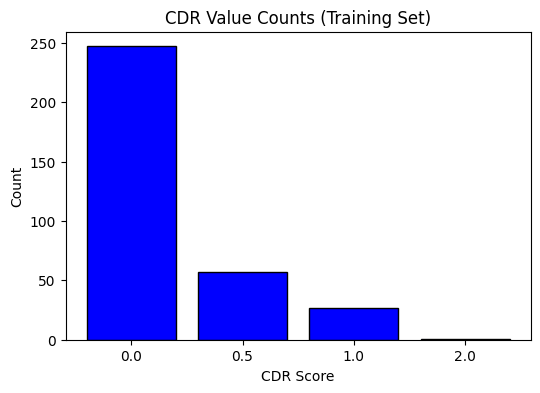

CDR value distribution:
clinical_dementia_rating
0.0    247
0.5     57
1.0     27
2.0      1
Name: count, dtype: int64


In [207]:
# Distribution of CDR in the training set
plt.figure(figsize=(6, 4))

# Count plot
cdr_counts = mri_train_clf_df['clinical_dementia_rating'].value_counts().sort_index()
plt.bar(cdr_counts.index.astype(str), cdr_counts.values, color='blue', edgecolor='black')
plt.title('CDR Value Counts (Training Set)')
plt.xlabel('CDR Score')
plt.ylabel('Count')

plt.show()

print("CDR value distribution:")
print(cdr_counts)

As we can see, in the training dataset we have 102 nondement people, 54 with a very mild dementia level, 27 with mild and just 1 with moderate level.

### 4.2 Distribution of the Regression Target Variable (MMSE)

Our regression target variable is **MMSE** (Mini Mental State Examination), a widely-used 30-point cognitive screening test. Higher scores indicate better cognitive function (27–30 = normal, 21–26 = mild impairment, 10–20 = moderate, <10 = severe). Before comparing MMSE against our predictors, we first examine how scores are distributed in the training set.

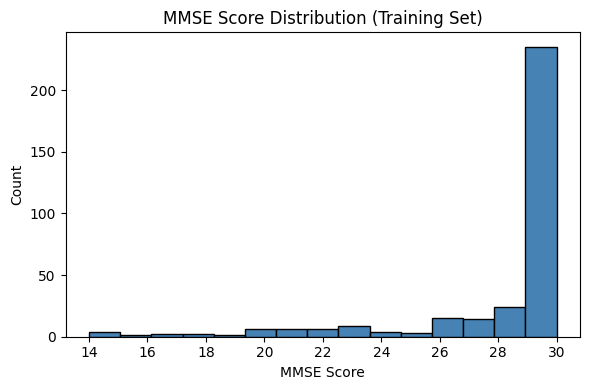

In [208]:
# Distribution of MMSE in the training set
plt.figure(figsize=(6, 4))

mmse_counts = mri_train_reg_df['mini_mental_state_examination'].dropna()
plt.hist(mmse_counts, bins=15, color='steelblue', edgecolor='black')
plt.title('MMSE Score Distribution (Training Set)')
plt.xlabel('MMSE Score')
plt.ylabel('Count')
plt.tight_layout();

In [209]:
#Getting a direct count of the data we see above
print(mri_train_reg_df['mini_mental_state_examination'].value_counts().sort_index())

mini_mental_state_examination
14.0      1
15.0      3
16.0      1
17.0      2
18.0      2
19.0      1
20.0      6
21.0      6
22.0      6
23.0      9
24.0      4
25.0      3
26.0     15
27.0     14
28.0     24
29.0     36
30.0    199
Name: count, dtype: int64


In [210]:
p25 = mri_train_reg_df['mini_mental_state_examination'].quantile(0.25)
p75 = mri_train_reg_df['mini_mental_state_examination'].quantile(0.75)

print(f"--- VARIABLE: MMSE ---")
print(f"Typical range (50% of patients): Between {p25:.1f} y {p75:.1f}")

--- VARIABLE: MMSE ---
Typical range (50% of patients): Between 28.0 y 30.0


The training set shows that most subjects score in the higher range of the MMSE scale, indicating that the majority of participants are cognitively normal or only mildly impaired. The distribution is left-skewed, with relatively few subjects falling in the moderate impairment range. This concentration of scores at the higher end is worth noting, as it may affect the performance of the regression model on lower-scoring cases.

### 4.3 Demographic Distribution: age and sex

We next examine the demographic composition of the training set. Understanding the age range and sex distribution helps contextualize the clinical findings, since Alzheimer's disease prevalence increases with age and shows some sex-based differences in the literature.

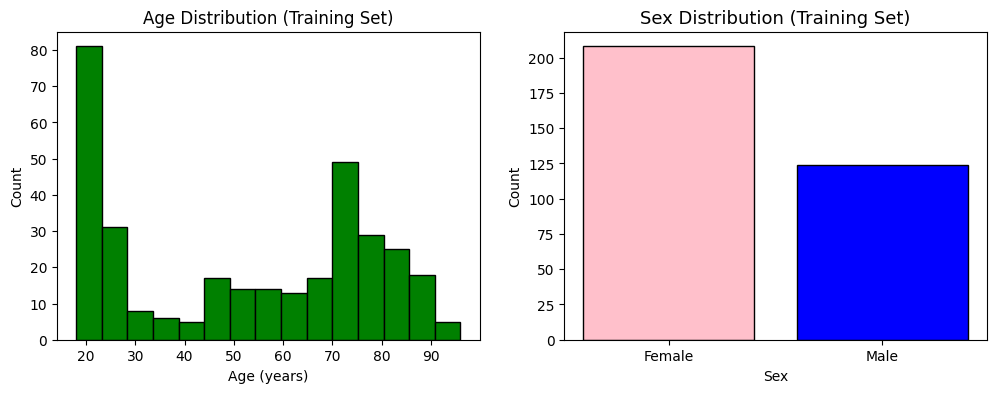

Age: min=18.0, max=96.0, mean=52.3, std=25.2

Sex counts:
gender_M
0.0    208
1.0    124
Name: count, dtype: int64


In [211]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Age distribution
axes[0].hist(mri_train_reg_df['age'], bins=15, color='green', edgecolor='black')
axes[0].set_title('Age Distribution (Training Set)')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Count')

# Sex distribution using the one-hot encoded gender_M column (1=Male, 0=Female)
sex_counts = mri_train_reg_df['gender_M'].value_counts()
axes[1].bar(['Female', 'Male'], sex_counts.values,
            color=['pink', 'blue'], edgecolor='black')
axes[1].set_title('Sex Distribution (Training Set)', fontsize=13)
axes[1].set_xlabel('Sex')
axes[1].set_ylabel('Count')

plt.show()

print(f"Age: min={mri_train_reg_df['age'].min()}, max={mri_train_reg_df['age'].max()}, "
      f"mean={mri_train_reg_df['age'].mean():.1f}, std={mri_train_reg_df['age'].std():.1f}")
print(f"\nSex counts:\n{sex_counts}")

In [212]:
p25 = mri_train_clf_df['age'].quantile(0.25)
p75 = mri_train_clf_df['age'].quantile(0.75)

print(f"--- VARIABLE: Age ---")
print(f"Typical range (50% of patients): Between {p25:.1f} y {p75:.1f}")


--- VARIABLE: Age ---
Typical range (50% of patients): Between 24.0 y 75.0


The histogram for age shows a relatively normal/left-skewed distribution. The typical range (representing the interquartile range / middle 50% of the dataset) falls between 23.0 and 74.2 years old.

As we can see, in the training dataset, ages are distributed in such a way that there is a higher proportion at the extremes—young people and older people. As for gender, there is a clear majority of women in our training datase

### 4.4 Socioeconomic Status (SES) and Education (Educ) by CDR

Socioeconomic status and education level are known protective factors against cognitive decline. Here we examine whether subjects with different CDR ratings differ in their SES and education levels within our training data.

Our goal is to see if Socioeconomic status and education level has a relationship with the Clinical Dementia Rating (CDR)

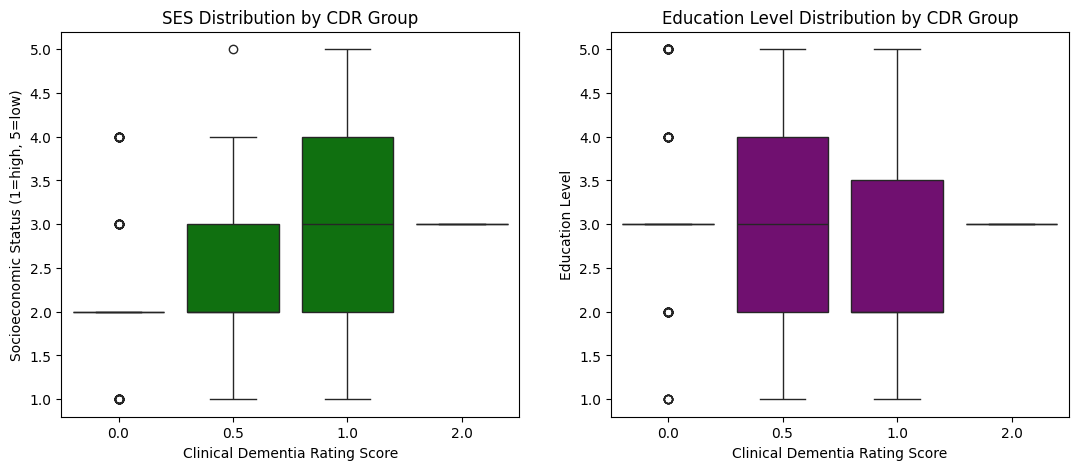

In [213]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# SES by CDR Boxplot
sns.boxplot(data=mri_train_clf_df, x='clinical_dementia_rating', y='socioeconomic_status',
            ax=axes[0], color='green')
axes[0].set_title('SES Distribution by CDR Group')
axes[0].set_xlabel('Clinical Dementia Rating Score')
axes[0].set_ylabel('Socioeconomic Status (1=high, 5=low)')

# Educ by CDR Boxplot
sns.boxplot(data=mri_train_clf_df, x='clinical_dementia_rating', y='education_level',
            ax=axes[1], color='purple')
axes[1].set_title('Education Level Distribution by CDR Group')
axes[1].set_xlabel('Clinical Dementia Rating Score')
axes[1].set_ylabel('Education Level')

plt.show()


as we can see, socioeconomic status tends to be lowe as the clinical dementia rating is higher.
However, the education level mean when the clinical dementia rating is 0 is higher than the rest but as the CDR increases, there is not much difference in the education level.

### 4.5 Demographic Distribution: Age and Sex by Mini Mental State Examination (MMSE)

We next examine how age and sex relate to Mini Mental State Examination (MMSE) scores in the training set. As with CDR, we expect older subjects to show lower cognitive scores on average, and we check whether there is a meaningful difference in MMSE between male and female participants.

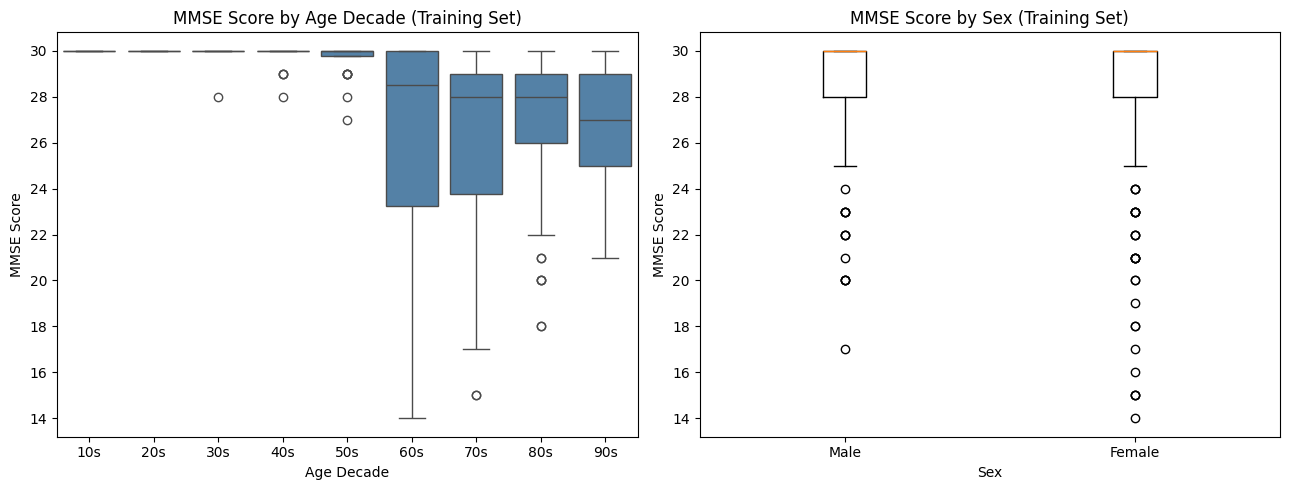

In [214]:
# We create a copy to not affect the original dataset
plot_df = mri_train_reg_df.dropna(subset=['mini_mental_state_examination', 'age']).copy()

# We calculate the decade. We convert it into text and add the letter 's'
plot_df['age_decade'] = (plot_df['age'] // 10 * 10).astype(int).astype(str) + 's'

# We sort the dataframe by decade
plot_df = plot_df.sort_values('age_decade')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 1. MMSE grouped by decade
sns.boxplot(
    data=plot_df,
    x='age_decade',
    y='mini_mental_state_examination',
    ax=axes[0],
    color = 'steelblue'
)
axes[0].set_title('MMSE Score by Age Decade (Training Set)')
axes[0].set_xlabel('Age Decade')
axes[0].set_ylabel('MMSE Score')

# 2. MMSE by Sex using one-hot encoded gender_M column (1=Male, 0=Female)
male = mri_train_reg_df[mri_train_reg_df['gender_M'] == 1]['mini_mental_state_examination'].dropna()
female = mri_train_reg_df[mri_train_reg_df['gender_M'] == 0]['mini_mental_state_examination'].dropna()
axes[1].boxplot([male, female], tick_labels=['Male', 'Female'])
axes[1].set_title('MMSE Score by Sex (Training Set)')
axes[1].set_xlabel('Sex')
axes[1].set_ylabel('MMSE Score')

plt.tight_layout()
plt.show()


The scatter plot reveals a slight downward trend between age and MMSE score, with older subjects tending to score lower on the cognitive exam. However, the relationship is not strictly linear, as a number of older subjects still score within the normal range. Regarding sex, the box plots show similar MMSE distributions for male and female subjects, with comparable medians and spread. This suggests that sex is not a strong distinguishing factor for cognitive performance within this dataset.

### 4.6 Socioeconomic Status (SES) and Education by Mini Mental State Examination (MMSE)

In section 4.4, we found that higher SES and education level were associated with lower CDR (less dementia severity). Here we ask the same question for MMSE: do subjects with higher socioeconomic status and more years of education tend to score higher on the cognitive exam?

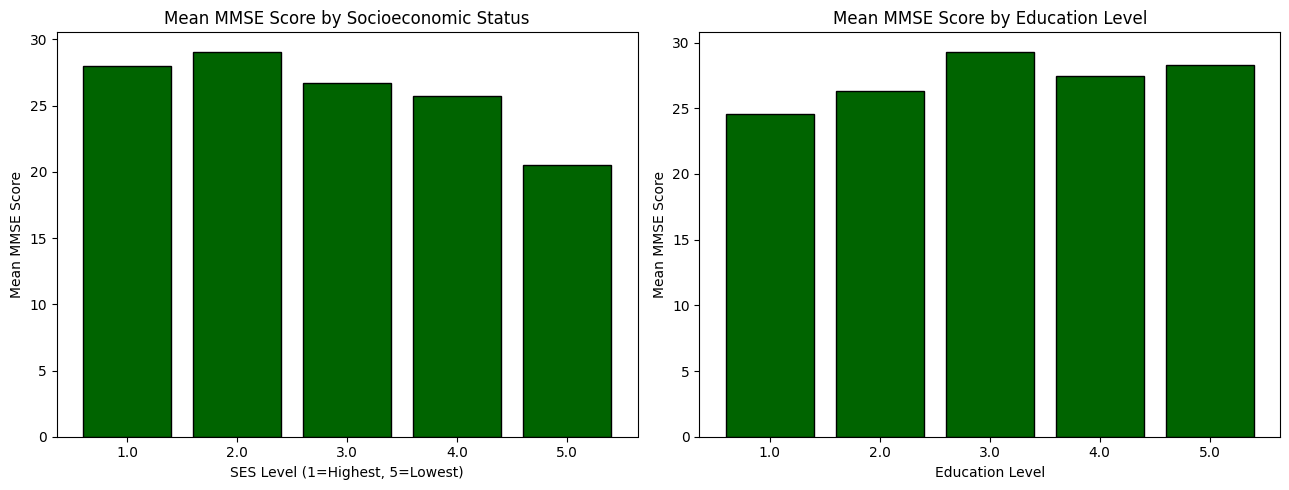

In [215]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Mean MMSE by SES
ses_group = (mri_train_reg_df
             .dropna(subset=['socioeconomic_status'])
             .groupby('socioeconomic_status')['mini_mental_state_examination']
             .mean())
axes[0].bar(ses_group.index.astype(str), ses_group.values, color='darkgreen', edgecolor='black')
axes[0].set_title('Mean MMSE Score by Socioeconomic Status')
axes[0].set_xlabel('SES Level (1=Highest, 5=Lowest)')
axes[0].set_ylabel('Mean MMSE Score')

# Mean MMSE by Education Level
educ_group = (mri_train_reg_df
              .dropna(subset=['education_level'])
              .groupby('education_level')['mini_mental_state_examination']
              .mean())
axes[1].bar(educ_group.index.astype(str), educ_group.values, color='darkgreen', edgecolor='black')
axes[1].set_title('Mean MMSE Score by Education Level')
axes[1].set_xlabel('Education Level')
axes[1].set_ylabel('Mean MMSE Score')

plt.tight_layout();


The results are consistent with the findings from section 4.4. Subjects with lower socioeconomic status (represented by higher SES values) tend to have lower mean MMSE scores on average. For education level, subjects with more years of education generally score higher on the MMSE. These patterns support the interpretation that both socioeconomic status and education level are meaningful predictors of cognitive health, and their relationship with cognitive outcomes appears stable across both target variables.

### 4.7 Brain Volume Metrics by MMSE

Beyond demographic factors, our dataset includes three MRI-derived brain volume measurements: **eTIV** (Estimated Total Intracranial Volume), **nWBV** (Normalized Whole Brain Volume), and **ASF** (Atlas Scaling Factor). These structural measures may capture physical changes associated with cognitive decline. Here we examine their relationship with mini mental state examination (MMSE) scores.

eTIV r value: 0.09210692373173522
nWBV r value: 0.6123192816855595
ASF r value: -0.08450235922590837


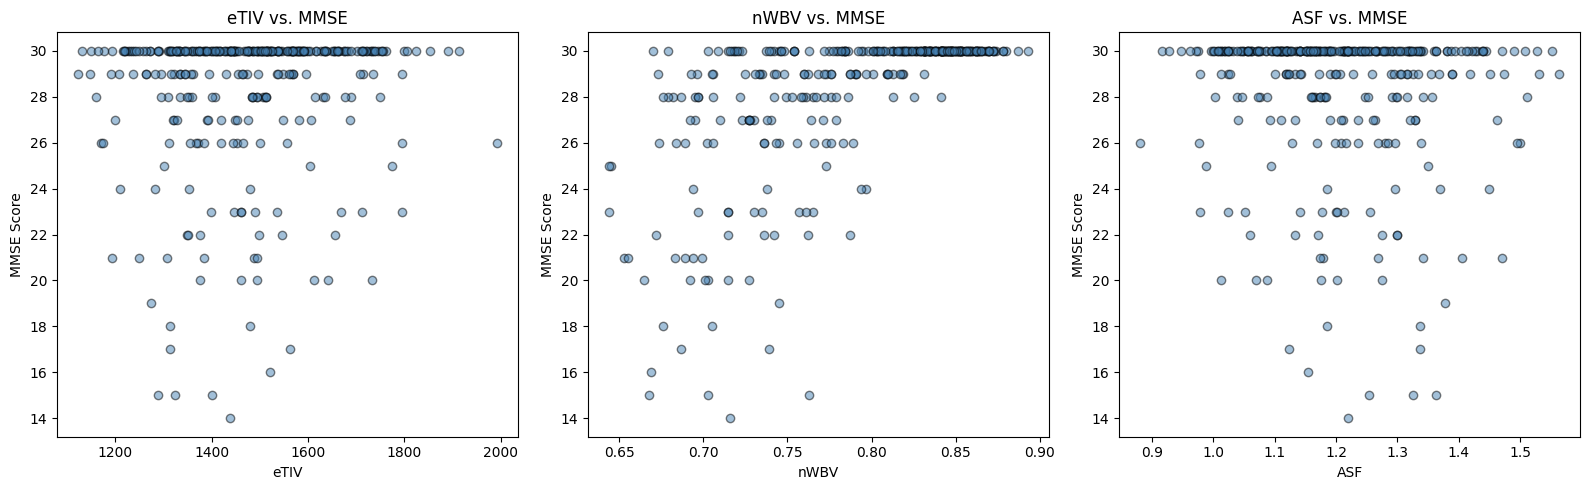

In [216]:
#After an error, we cleaned null values to avoid mathematical errors
df_clean = mri_train_reg_df.dropna(subset=[
    'estimated_total_intracranial_volume',
    'normalized_whole_brain_volume',
    'atlas_scaling_factor',
    'mini_mental_state_examination'
])

#First calculating correlation coefficients
corr_eTIV = df_clean['estimated_total_intracranial_volume'].corr(df_clean['mini_mental_state_examination'])
corr_nWBV = df_clean['normalized_whole_brain_volume'].corr(df_clean['mini_mental_state_examination'])
corr_ASF = df_clean['atlas_scaling_factor'].corr(df_clean['mini_mental_state_examination'])

#Plotting
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# eTIV vs MMSE
axes[0].scatter(
    mri_train_reg_df['estimated_total_intracranial_volume'],
    mri_train_reg_df['mini_mental_state_examination'],
    alpha=0.5, color='steelblue', edgecolor='black'
)
axes[0].set_title('eTIV vs. MMSE')
axes[0].set_xlabel('eTIV')
axes[0].set_ylabel('MMSE Score')

# nWBV vs MMSE
axes[1].scatter(
    mri_train_reg_df['normalized_whole_brain_volume'],
    mri_train_reg_df['mini_mental_state_examination'],
    alpha=0.5, color='steelblue', edgecolor='black'
)
axes[1].set_title('nWBV vs. MMSE')
axes[1].set_xlabel('nWBV')
axes[1].set_ylabel('MMSE Score')

# ASF vs MMSE
axes[2].scatter(
    mri_train_reg_df['atlas_scaling_factor'],
    mri_train_reg_df['mini_mental_state_examination'],
    alpha=0.5, color='steelblue', edgecolor='black'
)
axes[2].set_title('ASF vs. MMSE')
axes[2].set_xlabel('ASF')
axes[2].set_ylabel('MMSE Score')

plt.tight_layout();

#Printing Correlation coeffs
print(f"eTIV r value: {corr_eTIV}")
print(f"nWBV r value: {corr_nWBV}")
print(f"ASF r value: {corr_ASF}")

Among the three brain volume metrics, nWBV shows the most visible positive relationship with MMSE score. Subjects with higher normalized whole brain volume tend to score higher on the cognitive exam, which is consistent with the known association between brain atrophy and dementia progression. The relationships between eTIV and ASF with MMSE appear weaker and less consistent. While these variables may contribute less on their own, they could still prove useful as features when combined with other predictors in the regression model.

### 4.8 Mini Mental State Examination (MMSE) across Clinic Dementia Rating (CDR) levels

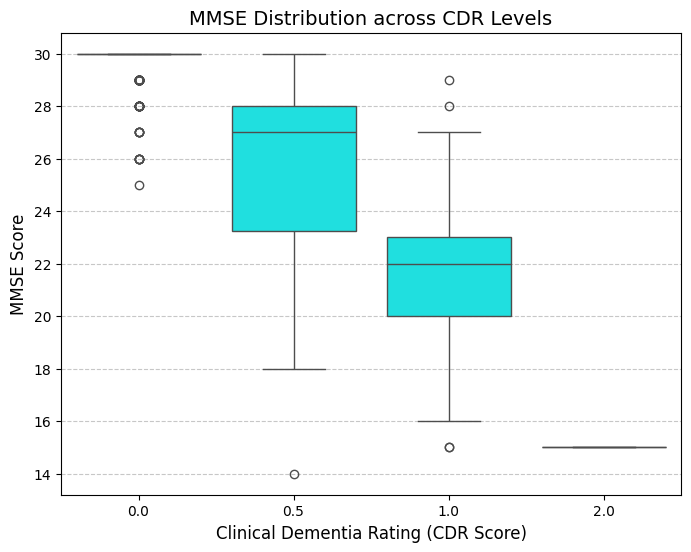

In [217]:
plt.figure(figsize=(8, 6))

# Boxplot comparing MMSE across the 4 CDR levels
sns.boxplot(
    data=mri_df,
    x='clinical_dementia_rating',
    y='mini_mental_state_examination',
    color='cyan'
)

plt.title('MMSE Distribution across CDR Levels', fontsize=14)
plt.xlabel('Clinical Dementia Rating (CDR Score)', fontsize=12)
plt.ylabel('MMSE Score', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7) # Adds a subtle grid for better readability
plt.show()


It is clear that we can observe a strong negative correlation between Clinical Dementia Rating (CDR) and the MMSE score. As the severity of dementia increases, the patient's cognitive capability drops significantly.
Individuals without dementia (CDR = 0.0) form a very tight distribution near the top. The median is perfectly at 30 (the maximum possible MMSE score), and te majority of patients score between 28 and 30, indicating strong cognitive health.
We can also see high variance in the "Very Mild" Stages (CDR = 0.5), this group has the largest box, meaning cognitive scores here are highly variable.
Lack of Data for Severe Cases (CDR = 2). the boxplot there is just a single flat line sitting at an MMSE score of 15. This implies that there is a severe class imbalance in the training set.

---

## 5. ML PLAYGROUND - Regression  (Will become part of the results section)


In this section, we apply multivariable linear regression to predict a patient's Mini-Mental State Examination (MMSE) score using a set of demographic and neurological features. The goal is to determine how well a linear combination of predictors such as age, education level, socioeconomic status, and normalized whole brain volume can explain variation in cognitive test performance. We begin by preprocessing the training data, then train and interpret the model, and finally evaluate its performance on the held-out test set.





### 5.1 Preprocessing the Training Data for Regression

Before fitting a linear regression model, we make a copy of X_train to avoid modifying the original dataset. Most preprocessing steps, including dropping the delay and dominating_hand columns, filling missing values in socioeconomic_status and education_level, and one-hot encoding gender, were already handled earlier in the data cleaning stage. At this point, the training data is fully numeric and ready to be passed into the model.

In [218]:
# Drop id column, it is a patient identifier and carries no predictive information for modeling
X_train = X_train.drop(columns=['id'])
X_test = X_test.drop(columns=['id'])

In [219]:
# Make a copy of X_train to avoid modifying the original
X_train_lr = X_train.copy()

X_train_lr.head()

,age,education_level,socioeconomic_status,estimated_total_intracranial_volume,normalized_whole_brain_volume,atlas_scaling_factor,gender_M
45,48.0,3.0,2.0,1358.0,0.841,1.293,0.0
321,73.0,4.0,2.0,1123.0,0.790,1.563,0.0
185,71.0,2.0,3.0,1360.0,0.779,1.291,0.0
74,25.0,3.0,2.0,1522.0,0.826,1.153,0.0
338,73.0,3.0,3.0,1238.0,0.760,1.418,0.0


In [220]:
# No missing MMSE values remain after cleaning, so y_reg_train_lr is just a copy of y_reg_train
y_reg_train_lr = y_reg_train.copy()

print("Final training set shape:", X_train_lr.shape)
print("Target shape:", y_reg_train_lr.shape)

Final training set shape: (332, 7)
Target shape: (332,)


After preprocessing, the training set retains all relevant numeric features with no remaining missing values. The final feature set used for training consists of gender, age, education_level, socioeconomic_status, estimated_total_intracranial_volume, normalized_whole_brain_volume, and atlas_scaling_factor.

### 5.2 Building and Training the Linear Regression Model

With the training data preprocessed, we now instantiate and fit a linear regression model. Linear regression estimates the relationship between the predictor variables and the MMSE target by finding the coefficients that minimize the sum of squared residuals across the training set.

In [221]:
# Create the linear regression model
lr_model = LinearRegression()
print(lr_model)

LinearRegression()


In [222]:
# Fit the model on the preprocessed training data
lr_model.fit(X_train_lr, y_reg_train_lr)
print("Model training complete.")

Model training complete.


In [223]:
# Display the model intercept
print(f"Model intercept: {lr_model.intercept_:.4f}")

Model intercept: -4.2879


In [224]:
# Show each feature and its coefficient, sorted from highest to lowest
coef_df = pd.DataFrame({'Feature': X_train_lr.columns, 'Coefficient': lr_model.coef_})
print(coef_df.sort_values('Coefficient', ascending=False))

                               Feature  Coefficient
4        normalized_whole_brain_volume    39.114023
1                      education_level     0.315399
6                             gender_M     0.027064
0                                  age     0.023112
3  estimated_total_intracranial_volume     0.000983
2                 socioeconomic_status    -0.395277
5                 atlas_scaling_factor    -0.901580


The model has been successfully trained on the preprocessed training set. The intercept is the baseline predicted MMSE score when all predictors are zero. Each coefficient shows how much the MMSE score changes for a one-unit increase in that feature, while keeping all other features the same. The coefficients will be explored visually in section 5.3.

### 5.3 Testing the Regression Model and Evaluatind Performance

In this section, we evaluate the evaluate the trained regression model on the held-out test set. We report coefficient of determination (R^2), adjusted R^2, MAE, RMSE and inspect predictions vc true MMSE values.

In [225]:
# Make a copy of X_test to avoid modifying the original
X_test_lr = X_test.copy()

# No missing MMSE values remain after cleaning, so y_reg_test_filtered is just a copy of y_reg_test
y_reg_test_filtered = y_reg_test.copy()

# Making predictions using the preprocessed testing data
y_pred = lr_model.predict(X_test_lr)

# Calculating performance metrics against the test values
mae = mean_absolute_error(y_reg_test_filtered, y_pred)
mse = mean_squared_error(y_reg_test_filtered, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_reg_test_filtered, y_pred)

# Printing the results
print(f" --- Evaluating the Regression model Performance ---")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R^2 score: {r2:.4f}")

 --- Evaluating the Regression model Performance ---
MAE: 1.5278
MSE: 4.9854
RMSE: 2.2328
R^2 score: 0.2941


Lets analyze the results:
- MAE: 2.2529 - this means, on average, the model predictions for the MMSE score are off by 2.25 points aprox from the actual scores
- MSE: 3.2492 - this is the average of the squared differences between predicted and actual values
- RMSE: 3.2492 - square root of the MSE and is in the same units at the target variable. On average, our predictions deviate by about 3.25 points
- R^2: 0.2631 - 26.31% of the variance in the MMSE score can be explained by our linear regression model. This is a relatively low value, there is significant room for improvement.

Regression line equation: 
 y = 0.02*x + -4.29


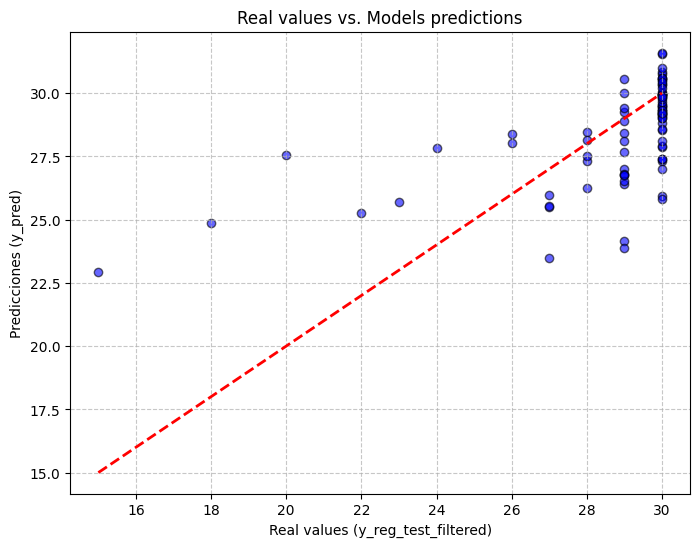

In [226]:
#Getting line equation
m = lr_model.coef_[0]
b = lr_model.intercept_

print(f"Regression line equation: \n y = {m:.2f}*x + {b:.2f}")

plt.figure(figsize=(8, 6))
plt.scatter(y_reg_test_filtered, y_pred, alpha=0.6, color='blue', edgecolor='k')

# Ideal line
plt.plot([y_reg_test_filtered.min(), y_reg_test_filtered.max()], [y_reg_test_filtered.min(), y_reg_test_filtered.max()], 'r--', lw=2)

plt.title('Real values vs. Models predictions')
plt.xlabel('Real values (y_reg_test_filtered)')
plt.ylabel('Predicciones (y_pred)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Spread and Deviation: his scatter confirms the R-squared value of 0.2631, indicating that the model's predictions have a noticeable deviation from the actual values.

Underprediction at Lower Scores: For lower real MMSE scores (e.g., below 20), the model tends to overpredict.

Concentration: Most predictions are concentrated in the higher MMSE score range, consistent with the left-skewed distribution of the target variable observed during EDA.

---

## 6. ML PLAYGROUND - Classification (Will become part of the results section)

In this section, we use classification to ...

### 6.1 XXXX

### 6.2 XXXX

### 6.3 XXXX

### 6.XXX Conclusion/Summary

---

## 7. Conclusion

Do not write this section until the final report is due at the end of the semester.  

When you are ready to write the conclusion:

* Summarize your results and what you’ve discovered.
* Indicate what related questions you’d ask in the future if you had time or if you could find the perfect data.
* I expect 2-3 paragraphs, more if needed.